## 1. Import Required Libraries

In [1]:
import  numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns 
import warnings 
warnings.filterwarnings("ignore")

## 2. Load the Dataset


In [2]:
df = pd.read_csv("titanic.csv")
df

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C


## 3. Initial Dataset Health Check
Let us understand the structure and basic statistics of the dataset.


In [3]:
df.shape

(891, 12)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [5]:
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


## 4. Missing Value Analysis
We identify missing values and calculate their percentage to make informed decisions.

In [6]:
missing_count = df.isnull().sum()

missing_percent = (missing_count / len(df))* 100

pd.DataFrame({
    "Missing_count": missing_count,
    "Missing_percentage":missing_percent
}).sort_values(by = "Missing_percentage",ascending = False)

,Missing_count,Missing_percentage
Cabin,687,77.104377
Age,177,19.865320
Embarked,2,0.224467
PassengerId,0,0.000000
Survived,0,0.000000
Pclass,0,0.000000
Name,0,0.000000
Sex,0,0.000000
SibSp,0,0.000000
Parch,0,0.000000


### Cleaning Strategy (Decision-Based)

- **Age** → Numerical column, slightly skewed → Fill with median  
- **Embarked** → Categorical column with very few missing → Fill with mode  
- **Cabin** → Very high missing percentage → Drop the column

In [7]:

df["Age"].fillna(df["Age"].median(), inplace = True)

In [8]:
df["Embarked"].fillna(df["Embarked"].mode()[0], inplace=True)
df.drop(columns=['Cabin'], inplace=True, errors='ignore')

In [9]:
df.isnull().sum()

PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
dtype: int64

## 5. Handling Duplicate Records
Duplicates can lead to biased analysis and incorrect model learning.


In [10]:
df.duplicated().sum()

np.int64(0)

## 6. Cleaning Categorical Data
We standardize text data to avoid category mismatch.

In [11]:
df["Sex"] = df["Sex"].str.lower()
df["Embarked"] = df["Embarked"].str.strip()

In [12]:
df["Sex"]

0        male
1      female
2      female
3      female
4        male
        ...  
886      male
887    female
888    female
889      male
890      male
Name: Sex, Length: 891, dtype: object

In [13]:
df["Embarked"]

0      S
1      C
2      S
3      S
4      S
      ..
886    S
887    S
888    S
889    C
890    Q
Name: Embarked, Length: 891, dtype: object

## 7. Outlier Detection – Fare Column
We use a boxplot to visually identify outliers.

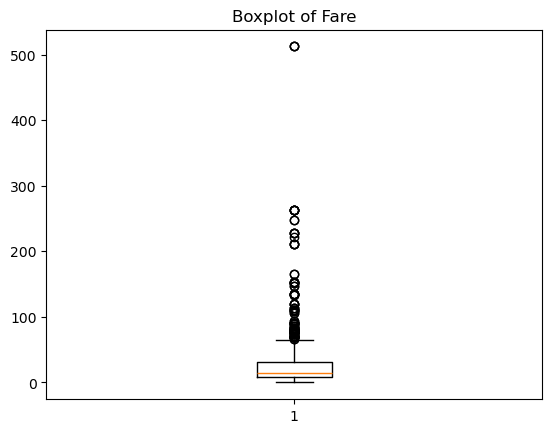

In [14]:
plt.boxplot(df["Fare"])
plt.title("Boxplot of Fare")
plt.show()

### Insights:
- Fare is **right-skewed**, indicating some passengers paid very high prices
- Several extreme values are present beyond the upper whisker
- These outliers can significantly affect mean and variance
- Outliers may represent premium cabins and should not be blindly removed

## 8. Treating Outliers Using IQR Method (Capping)
Instead of removing outliers, we cap them to preserve data size.

In [15]:
# lower ----> iqr -----> q3 /q1------> 75 & 25th percent value 

Q1 = df["Fare"].quantile(0.25)
Q3 = df["Fare"].quantile(0.75)

IQR = Q3- Q1

lower_whisker = Q1 - 1.5* IQR
upper_whisker = Q3 + 1.5* IQR

In [16]:
df["Fare"] = np.where(df["Fare"] > upper_whisker ,upper_whisker , df["Fare"])
df["Fare"] = np.where(df["Fare"] < lower_whisker , lower_whisker , df["Fare"])



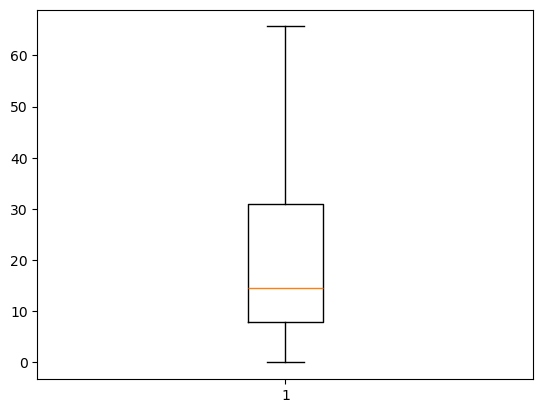

In [17]:
plt.boxplot(df["Fare"])
plt.show()

## 10. Dropping Irrelevant Columns
These columns do not add predictive or analytical value.

In [19]:

df.drop(columns = ["PassengerId","Name","Ticket"], inplace = True)

In [20]:
df

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,0,3,male,22.0,1,0,7.2500,S
1,1,1,female,38.0,1,0,65.6344,C
2,1,3,female,26.0,0,0,7.9250,S
3,1,1,female,35.0,1,0,53.1000,S
4,0,3,male,35.0,0,0,8.0500,S
...,...,...,...,...,...,...,...,...
886,0,2,male,27.0,0,0,13.0000,S
887,1,1,female,19.0,0,0,30.0000,S
888,0,3,female,28.0,1,2,23.4500,S
889,1,1,male,26.0,0,0,30.0000,C


## 11. Standardizing Column Names
We convert column names to lowercase for consistency.

In [21]:
df.rename(columns = lambda x :x.lower(),inplace = True)

## 12. Final Dataset Validation
We confirm that all cleaning steps were successful.

In [22]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 8 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   survived  891 non-null    int64  
 1   pclass    891 non-null    int64  
 2   sex       891 non-null    object 
 3   age       891 non-null    float64
 4   sibsp     891 non-null    int64  
 5   parch     891 non-null    int64  
 6   fare      891 non-null    float64
 7   embarked  891 non-null    object 
dtypes: float64(2), int64(4), object(2)
memory usage: 55.8+ KB


In [23]:
df.isnull().sum()

survived    0
pclass      0
sex         0
age         0
sibsp       0
parch       0
fare        0
embarked    0
dtype: int64

## FEW EXTRA ANALYSIS PROBLEM STATEMENT

In [24]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 8 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   survived  891 non-null    int64  
 1   pclass    891 non-null    int64  
 2   sex       891 non-null    object 
 3   age       891 non-null    float64
 4   sibsp     891 non-null    int64  
 5   parch     891 non-null    int64  
 6   fare      891 non-null    float64
 7   embarked  891 non-null    object 
dtypes: float64(2), int64(4), object(2)
memory usage: 55.8+ KB


## Which columns have the most missing values?

In [25]:

missing_values = df.isnull().sum()


missing_values_sorted = missing_values.sort_values(ascending=False)

print(missing_values_sorted)



survived    0
pclass      0
sex         0
age         0
sibsp       0
parch       0
fare        0
embarked    0
dtype: int64


In [26]:
df.isnull().sum()

survived    0
pclass      0
sex         0
age         0
sibsp       0
parch       0
fare        0
embarked    0
dtype: int64

## How many duplicate rows exist?

In [27]:
df.duplicated().sum()

np.int64(123)

In [28]:
df = df.drop_duplicates()

In [29]:
df.duplicated().sum()

np.int64(0)

In [30]:
df.isnull().sum()

survived    0
pclass      0
sex         0
age         0
sibsp       0
parch       0
fare        0
embarked    0
dtype: int64

## Convert “male”, “Male”, “M” → “Male”

In [31]:
df['sex'] = df['sex'].replace(['male', 'Male', 'M'], 'Male')
df

,survived,pclass,sex,age,sibsp,parch,fare,embarked
0,0,3,Male,22.0,1,0,7.2500,S
1,1,1,female,38.0,1,0,65.6344,C
2,1,3,female,26.0,0,0,7.9250,S
3,1,1,female,35.0,1,0,53.1000,S
4,0,3,Male,35.0,0,0,8.0500,S
...,...,...,...,...,...,...,...,...
885,0,3,female,39.0,0,5,29.1250,Q
887,1,1,female,19.0,0,0,30.0000,S
888,0,3,female,28.0,1,2,23.4500,S
889,1,1,Male,26.0,0,0,30.0000,C


## Clean spaces in string columns

In [32]:
for col in df.select_dtypes(include='object').columns:
    df[col] = df[col].str.strip()

df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked
0,0,3,Male,22.0,1,0,7.2500,S
1,1,1,female,38.0,1,0,65.6344,C
2,1,3,female,26.0,0,0,7.9250,S
3,1,1,female,35.0,1,0,53.1000,S
4,0,3,Male,35.0,0,0,8.0500,S


## Convert AGE column to numeric INT

In [33]:
df['age'] = pd.to_numeric(df['age'], errors='coerce')
df


,survived,pclass,sex,age,sibsp,parch,fare,embarked
0,0,3,Male,22.0,1,0,7.2500,S
1,1,1,female,38.0,1,0,65.6344,C
2,1,3,female,26.0,0,0,7.9250,S
3,1,1,female,35.0,1,0,53.1000,S
4,0,3,Male,35.0,0,0,8.0500,S
...,...,...,...,...,...,...,...,...
885,0,3,female,39.0,0,5,29.1250,Q
887,1,1,female,19.0,0,0,30.0000,S
888,0,3,female,28.0,1,2,23.4500,S
889,1,1,Male,26.0,0,0,30.0000,C


In [34]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 768 entries, 0 to 890
Data columns (total 8 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   survived  768 non-null    int64  
 1   pclass    768 non-null    int64  
 2   sex       768 non-null    object 
 3   age       768 non-null    float64
 4   sibsp     768 non-null    int64  
 5   parch     768 non-null    int64  
 6   fare      768 non-null    float64
 7   embarked  768 non-null    object 
dtypes: float64(2), int64(4), object(2)
memory usage: 54.0+ KB


## Find invalid or suspicious values

In [35]:
df.isnull().sum()

survived    0
pclass      0
sex         0
age         0
sibsp       0
parch       0
fare        0
embarked    0
dtype: int64

In [36]:
df.duplicated().sum()

np.int64(0)

In [37]:
df.duplicated().sum()

np.int64(0)

In [38]:
df[df['age'] < 0]
df[df['age'] > 100]

,survived,pclass,sex,age,sibsp,parch,fare,embarked


In [40]:
df.describe()

,survived,pclass,age,sibsp,parch,fare
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,0.407552,2.257812,29.574766,0.528646,0.423177,25.164488
std,0.491699,0.849076,13.821635,0.993702,0.843309,20.491106
min,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,0.000000,1.000000,21.000000,0.000000,0.000000,8.050000
50%,0.000000,3.000000,28.000000,0.000000,0.000000,15.850000
75%,1.000000,3.000000,36.000000,1.000000,1.000000,32.625000
max,1.000000,3.000000,80.000000,8.000000,6.000000,65.634400


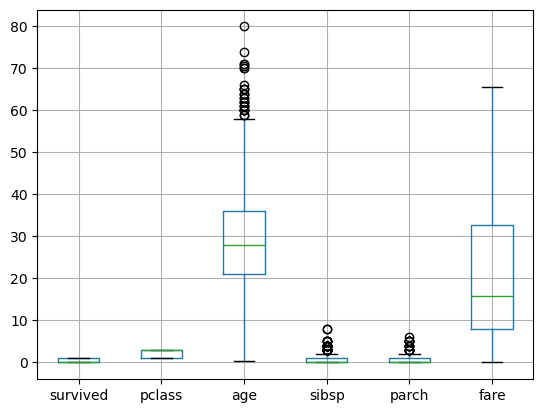

In [41]:
import matplotlib.pyplot as plt

df.boxplot()
plt.show()

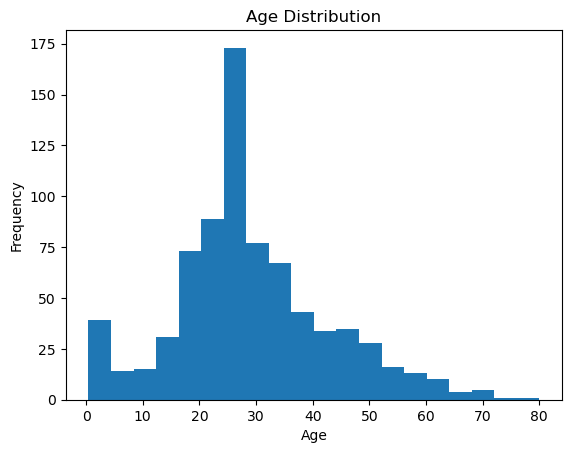

In [42]:
import matplotlib.pyplot as plt

df['age'].plot(kind='hist', bins=20)
plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Frequency")
plt.show()

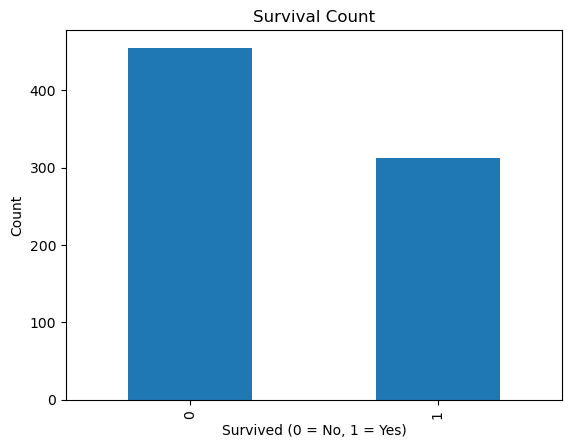

In [43]:
df['survived'].value_counts().plot(kind='bar')
plt.title("Survival Count")
plt.xlabel("Survived (0 = No, 1 = Yes)")
plt.ylabel("Count")
plt.show()

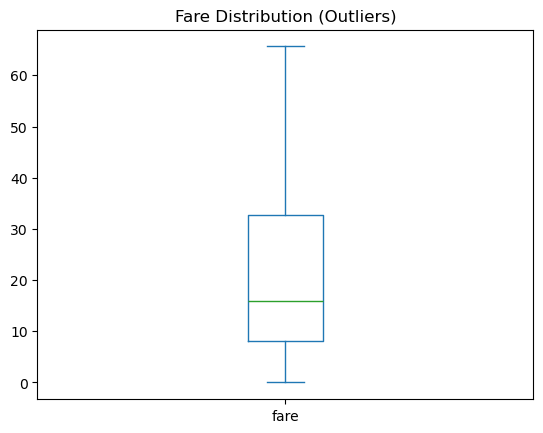

In [44]:
df['fare'].plot(kind='box')
plt.title("Fare Distribution (Outliers)")
plt.show()

#  Titanic Dataset – Final Insights 

##  Key Insights

###  Insight 1: High Missing Data in Cabin

The Cabin column had a very high number of missing values (687 out of 891), indicating that cabin information was not recorded for most passengers. Due to this, the column was removed.

---

###  Insight 2: Age Missing Values Handled

The Age column had 177 missing values, which were filled using the median. This helped maintain the overall distribution without being affected by extreme values.

---

###  Insight 3: Embarked Column Nearly Complete

The Embarked column had only 2 missing values, which were filled using the mode. This ensured consistency in categorical data with minimal impact.

---

###  Insight 4: No Duplicate Records Found

The dataset contains no duplicate rows after cleaning, indicating good data integrity and no repeated passenger records.

---

###  Insight 5: Dataset Fully Cleaned

After data cleaning, all columns contain zero missing values, making the dataset complete and suitable for further analysis and modeling.



In [45]:
df.to_csv("cleaned_titanic.csv", index=False)